In [1]:
import torch
import umap
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from zadu import zadu
import torch
from pcc import PCC, PCUMAP
from pcc.metrics import Metrics
from msi_atlas.annotations import get_annotations
from pcc.metrics import Metrics
from sklearn.cluster import KMeans
import torch
from torchdr import UMAP
from msi_visual.utils import normalize
from importlib import reload
from PIL import Image
from pcc import PCC
import cv2
from msi_visual.normalization import spatial_total_ion_count
import cuml

mouse_index = 0
X = np.load(f"/home/jacob/Desktop/{mouse_index}.npy")
X = X / (1e-6 + X.sum(axis=-1, keepdims=True))
X = np.float32(X)
X = X.transpose().transpose(1, 2, 0)[::-1, :, :].copy()
X_1d = np.reshape(X, (-1, X.shape[-1])).copy()
X_raw = X_1d.copy()

/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-23 21:19:26.371637: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 21:19:26.401680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 21:19:27.073728: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly di

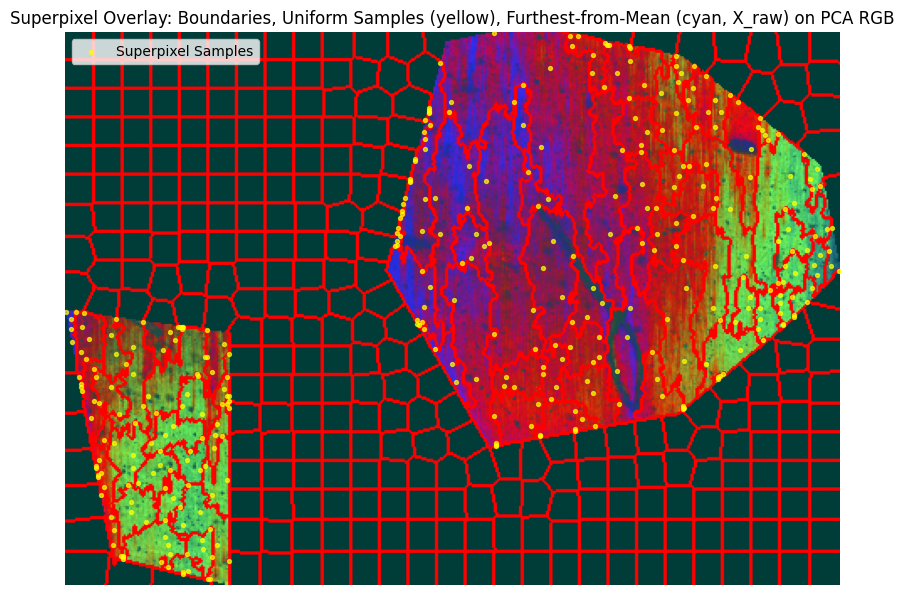

(363,)


In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.feature import canny
from skimage.color import rgb2gray

mask = X.sum(axis=-1) > 0

# 1. PCA for RGB mapping
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_raw)
X_rgb = X_pca - X_pca.min(axis=0)
X_rgb = X_rgb / (X_rgb.max(axis=0) + 1e-8)
X_rgb = (X_rgb * 255).clip(0, 255).astype(np.uint8)

# 2. Reshape for image-like geometry (height, width, 3)
height, width = X.shape[0], X.shape[1]
X_rgb_img = X_rgb.reshape(height, width, 3)

# 3. Convert to float for SLIC
X_rgb_float = img_as_float(X_rgb_img)

# 4. Superpixel segmentation 
n_superpixels = 512  # adjust for how fine/coarse the segmentation is
mask_labels = slic(X_rgb_float, n_segments=n_superpixels, compactness=10, channel_axis=2, start_label=0)


#X_rgb_img = cv2.merge([cv2.equalizeHist(X_rgb_img[:,:,0]), cv2.equalizeHist(X_rgb_img[:,:,1]), cv2.equalizeHist(X_rgb_img[:,:,2])])

# Add: valid region mask (same shape as image, True if mask==1)
mask_img = mask.reshape(height, width)
valid_pixel_bool = mask_img.astype(bool)

# 5. Uniformly sample points from each superpixel, avoiding mask==0, and also avoiding uppermost region
points_per_superpixel = 40  # change as needed
sampled_coords = []
rng = np.random.default_rng(42)
for lbl in np.unique(mask_labels):
    coords = np.argwhere(mask_labels == lbl)
    coords_valid = np.array([coord for coord in coords if valid_pixel_bool[coord[0], coord[1]]])
    n = coords_valid.shape[0]
    if n == 0:
        continue
    if n <= points_per_superpixel:
        chosen = coords_valid
    else:
        # Uniform grid-like subsample over the superpixel
        idx_sort = np.lexsort((coords_valid[:, 1], coords_valid[:, 0]))  # sort by row,col for structure
        coords_valid_sorted = coords_valid[idx_sort]
        steps = max(1, n // points_per_superpixel)
        chosen = coords_valid_sorted[::steps][:points_per_superpixel]
    sampled_coords.append(chosen)
if len(sampled_coords) == 0:
    sampled_coords = np.empty((0, 2), dtype=int)
else:
    sampled_coords = np.concatenate(sampled_coords, axis=0)

# 6. For each region, sample points furthest from the mean spectrum (in X_raw)
# We'll use the PCA RGB image for blob detection.
# Convert to grayscale if needed
if X_rgb_img.ndim == 3:
    # Simple mean over channels for blob detection
    X_gray = X_rgb_img.mean(axis=2)
else:
    X_gray = X_rgb_img

# 6. Instead of blob detection, do: take region spectra, PCA, cluster, pick cluster centroids, map back to coordinates

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Get all valid (unmasked) pixel coordinates
valid_coords = np.argwhere(valid_pixel_bool)
# Get the spectra ("X_raw") for valid pixels
valid_spectra = X_raw[valid_coords[:,0] * width + valid_coords[:,1]]

# For each region (label in mask_labels), sample points furthest from the mean spectrum (in X_raw) separately and collect all results.

n_pca = 50
n_clusters_per_region = 1024  # Adjust as needed per region to get ~total points desired
farthest_coords = []

unique_labels = np.unique(mask_labels)

# for region_lbl in unique_labels:
#     # find coordinates in this region & valid
#     region_mask = (mask_labels == region_lbl) & valid_pixel_bool
#     region_coords = np.argwhere(region_mask)
#     if region_coords.shape[0] == 0:
#         continue
#     # get spectra for these pixels
#     region_indices = region_coords[:,0] * width + region_coords[:,1]
#     region_spectra = X_raw[region_indices]
#     # PCA
#     if region_spectra.shape[0] < n_pca:
#         n_components = min(n_pca, max(1, region_spectra.shape[0]))
#     else:
#         n_components = n_pca
#     pca = PCA(n_components=n_components, random_state=0)
#     region_pca = pca.fit_transform(region_spectra)
#     # KMeans: no more clusters than points
#     n_clusters = min(n_clusters_per_region, region_pca.shape[0])
#     if n_clusters < 1:
#         continue
#     kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
#     region_labels = kmeans.fit_predict(region_pca)
#     region_centers = kmeans.cluster_centers_
#     for i in range(n_clusters):
#         idxs = np.where(region_labels == i)[0]
#         if len(idxs) == 0:
#             continue
#         cluster_points = region_pca[idxs]
#         centroid = region_centers[i]
#         # Find the point closest to centroid
#         dists = np.linalg.norm(cluster_points - centroid, axis=1)
#         closest_idx = idxs[np.argmin(dists)]
#         farthest_coords.append(region_coords[closest_idx])

# farthest_coords = np.array(farthest_coords)

# 7. Combine all sampled points (superpixels + furthest from mean in X_raw)
if len(sampled_coords) == 0:
    all_sampled_coords = farthest_coords
elif len(farthest_coords) == 0:
    all_sampled_coords = sampled_coords
else:
    all_sampled_coords = np.vstack([sampled_coords, farthest_coords])
all_sampled_flat_indices = np.ravel_multi_index((all_sampled_coords[:, 0], all_sampled_coords[:, 1]), (height, width))
selected_data = X_raw[all_sampled_flat_indices]

# 8. Visualization: Show PCA RGB + overlays
fig, ax = plt.subplots(figsize=(10, 10))
img_with_boundaries = mark_boundaries(X_rgb_img, mask_labels, color=(1, 0, 0), mode='thick')
ax.imshow(img_with_boundaries)
if len(sampled_coords) > 0:
    ax.scatter(sampled_coords[:, 1], sampled_coords[:, 0], s=8, c='yellow', alpha=0.7, label='Superpixel Samples')
if len(farthest_coords) > 0:
    ax.scatter(farthest_coords[:, 1], farthest_coords[:, 0], s=6, c='cyan', alpha=0.8, label='Furthest-from-Mean (X_raw) Samples')
ax.axis('off')
ax.set_title("Superpixel Overlay: Boundaries, Uniform Samples (yellow), Furthest-from-Mean (cyan, X_raw) on PCA RGB")
ax.legend()
plt.show()

print(all_sampled_flat_indices.shape)

In [3]:
import numpy as np
from PIL import Image

def equalize_hist(image):
    """
    Apply histogram equalization to an input uint8 image (H, W, C) or (H, W).
    For multichannel image, apply equalization per channel.

    Args:
        image: Input numpy array (uint8), 2D (H, W) or 3D (H, W, C).

    Returns:
        Equalized image (same shape/type as input)."
    """
    if image.ndim == 2:
        # Grayscale
        flat = image.flatten()
        hist, bins = np.histogram(flat, 256, [0,256])
        cdf = hist.cumsum()
        cdf_masked = np.ma.masked_equal(cdf, 0)
        cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
        cdf_final = np.ma.filled(cdf_masked, 0).astype('uint8')
        return cdf_final[image]
    elif image.ndim == 3:
        out = np.empty_like(image)
        for c in range(image.shape[2]):
            out[...,c] = equalize_hist(image[...,c])
        return out
    else:
        raise ValueError("Input image must be 2D or 3D array")


def visualize(model, npy_files):
    """
    Visualize embeddings for a list of npy files using the given model.

    Args:
        model: The PyTorch model that produces (N, 3) outputs.
        npy_files: List of paths to .npy files to load and visualize.

    Returns:
        Horizontally stacked visualization image as a numpy uint8 array.
    """

    images = []
    for npy_file in npy_files:
        X = np.load(npy_file)
        X = X / (1e-6 + X.sum(axis=-1, keepdims=True))
        X = np.float32(X)
        X = X.transpose().transpose(1, 2, 0)[::-1, :, :].copy()
        X_1d = np.reshape(X, (-1, X.shape[-1])).copy()
        X_raw = X_1d.copy()

        model.eval()
        with torch.no_grad():
            batch_size = 1024 * 16
            results = []
            X_batches = torch.split(torch.from_numpy(X_raw), batch_size)
            for X_batch in X_batches:
                batch_result = model(X_batch.cuda()).cpu()
                results.append(batch_result)
            result = torch.cat(results).reshape((X.shape[0], X.shape[1], 3)).numpy()

        mask = X.sum(axis=-1) > 0
        global_contrast = np.uint8(255 * normalize(result, 0, 100))
        global_contrast[mask == 0] = 0
        global_contrast = equalize_hist(global_contrast)

        images.append(global_contrast)

    # Now stack all images horizontally
    if len(images) == 0:
        return None

    heights = [img.shape[0] for img in images]
    max_height = max(heights)
    channels = [img.shape[2] if len(img.shape) == 3 else 1 for img in images]
    max_channels = max(channels)

    # Ensure all images have the same number of channels (for stacking)
    padded_images = []
    for img in images:
        img_h, img_w = img.shape[0], img.shape[1]
        # Pad color dimension to 3 channels if needed
        if len(img.shape) == 2:  # grayscale
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 1:
            img = np.concatenate([img]*3, axis=-1)
        # Pad to max_height along top/bottom with zeros if shorter
        pad_top = 0
        pad_bottom = max_height - img_h
        pad_left = 0
        pad_right = 0
        pad_width = ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0))
        img_padded = np.pad(img, pad_width, mode='constant', constant_values=0)
        padded_images.append(img_padded)
    stacked = np.hstack(padded_images)
    return stacked

In [4]:
from umap import UMAP
from sklearn.cluster import KMeans
import torch

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)




# kmeans_1024 = KMeans(n_clusters=1024, random_state=42)
# kmeans_1024.fit(X_raw)
# X_raw = kmeans_1024.cluster_centers_


X_raw = X_raw[all_sampled_flat_indices, :]

cluster_list = []
for n_clusters in [16, 32, 64, 128]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_raw)
    cluster_list.append(labels)


In [5]:
import tqdm
import glob
from pcc.parametric_pcc import ParametricPCC

class ResidualBlock(torch.nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(dim, dim),
            torch.nn.BatchNorm1d(dim),
            torch.nn.GELU()
        )

    def forward(self, x):
        return x + self.layer(x)


models = []
factor = 1.0

params = [{"factor": 1.0, "warmup_epochs": 10, "temperature": 100, "lr": 1.0, "batch_size": 4096, "num_epochs": 500, "n_components": 3, "beta": 1.0, "k_epoch": 50, "cluster": True},
          {"factor": 1.0, "warmup_epochs": 5, "temperature": 100, "lr": 1.0, "batch_size": 4096, "num_epochs": 500, "n_components": 3, "beta": 1.0, "k_epoch": 5, "cluster": True},
          {"factor": 1.0, "warmup_epochs": 3, "temperature": 100, "lr": 1.0, "batch_size": 4096, "num_epochs": 500, "n_components": 3, "beta": 1.0, "k_epoch": 50, "cluster": True},
          {"factor": 1.0, "warmup_epochs": 2, "temperature": 100, "lr": 1.0, "batch_size": 4096, "num_epochs": 500, "n_components": 3, "beta": 1.0, "k_epoch": 50, "cluster": True},
          {"factor": 2.0, "warmup_epochs": 20, "temperature": 20, "lr": 1.0, "batch_size": 4096, "num_epochs": 500, "n_components": 3, "beta": 0.1, "k_epoch": 50, "cluster": True},
          ]

ensemble_models = []
images = []
#seeds = [42, 20, 0, 2]
seeds = [42]
for param in tqdm.tqdm(params):
    for seed in seeds:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)

        factor = param["factor"]
        model = torch.nn.Sequential(
            torch.nn.Linear(X_raw.shape[1], int(2048 * factor)),
            torch.nn.BatchNorm1d(int(2048 * factor)),
            torch.nn.GELU(),
            ResidualBlock(int(2048 * factor)),
            torch.nn.BatchNorm1d(int(2048 * factor)),
            torch.nn.GELU(),
            ResidualBlock(int(2048 * factor)),
            torch.nn.Linear(int(2048 * factor), 3)
        )
        

        model = model.cuda()
        pcc = ParametricPCC(num_points=1000, num_epochs=500, n_components=3, beta=param["beta"], k_epoch=param["k_epoch"],
            cluster=param["cluster"], batch_size=4096, temperature = param["temperature"], random_state=42, model=model, x=X_raw, y=cluster_list, lr=1.0, warmup_epochs=param["warmup_epochs"])
        for i in tqdm.tqdm(range(100)):
            pcc.step()
        model.eval()
        images.append(visualize(model, glob.glob(f"/home/jacob/Desktop/*.npy")))
        

display(Image.fromarray(np.vstack(images)))

 20%|██        | 1/5 [00:07<00:30,  7.54s/it]


KeyboardInterrupt: 

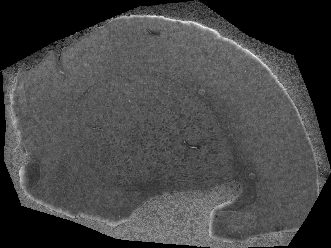

In [ ]:
X = np.load(f"/home/jacob/Desktop/msi_data/{1}.npy")
tic = X.sum(axis=-1)
tic =  tic / np.max(tic)
tic = np.uint8(255 * tic)

from scipy.ndimage import binary_erosion, binary_dilation




display(Image.fromarray(tic))